# DEIT

In [1]:
import subprocess, sys, warnings
warnings.filterwarnings("ignore")
for pkg in ["transformers", "datasets", "accelerate", "matplotlib"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
import torch
if not torch.cuda.is_available():
    raise RuntimeError
print("CUDA OK", torch.__version__)

CUDA OK 2.10.0+cu128


In [2]:
import json, os, csv, random
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from transformers import (DeiTForImageClassificationWithTeacher,DeiTImageProcessor,TrainingArguments,Trainer,EarlyStoppingCallback,)
from datasets import Dataset as HFDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix,)

import os

KAGGLE_INPUT_ROOT = "/kaggle/input/datasets/nikachuu/data-prep"
WORKING_CONFIG = "/kaggle/working/config.json"
INPUT_CONFIG = os.path.join(KAGGLE_INPUT_ROOT, "config.json")

def load_config():
    if os.path.isfile(WORKING_CONFIG):
        config_path = WORKING_CONFIG
    elif os.path.isfile(INPUT_CONFIG):
        config_path = INPUT_CONFIG
    else:
        raise FileNotFoundError
    with open(config_path) as f:
        config = json.load(f)
    roots = [config.get("dataset_path"),os.path.join(KAGGLE_INPUT_ROOT, "dataset"),"/kaggle/working/dataset",]
    for root in roots:
        if not root:
            continue
        train_ann = os.path.join(root, "train", "_annotations.coco.json")
        if os.path.isfile(train_ann):
            config["dataset_path"] = root
            config["train_ann"] = train_ann
            config["valid_ann"] = os.path.join(root, "valid", "_annotations.coco.json")
            config["test_ann"] = os.path.join(root, "test", "_annotations.coco.json")
            config["train_img_dir"] = os.path.join(root, "train")
            config["valid_img_dir"] = os.path.join(root, "valid")
            config["test_img_dir"] = os.path.join(root, "test")
            break
    else:
        raise FileNotFoundError
    config["save_dir"] = config.get("save_dir") or "/kaggle/working/results"
    os.makedirs(config["save_dir"], exist_ok=True)
    return config, config_path

config, CONFIG_PATH = load_config()

Experiment_Name = config["Experiment_Name"]
deit_variant = config["deit_variant"]
dataset_version = config["dataset_version"]
Confidence_Threshold = config["Confidence_Threshold"]
epochs_deit = config["epochs_deit"]
batch_size = config["batch_size"]
lr_deit = config["lr_deit"]
weight_decay = config["weight_decay"]
PATIENCE = config["PATIENCE"]
SEED = config["SEED"]
BASELINE_ACC = config["BASELINE_ACC"]
save_dir = config["save_dir"]
train_ann = config["train_ann"]
valid_ann = config["valid_ann"]
test_ann = config["test_ann"]
train_img_dir = config["train_img_dir"]
valid_img_dir = config["valid_img_dir"]
test_img_dir = config["test_img_dir"]
log_file = os.path.join(save_dir, "results.csv")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(save_dir, exist_ok=True)

def log_result(exp, model, acc, prec, rec, f1, thresh, variant, ds_ver, notes=""):
    row = {"timestamp": datetime.now().isoformat(timespec="seconds"),"experiment": exp, "model": model,"accuracy": f"{acc:.2f}", "precision": f"{prec:.2f}","recall": f"{rec:.2f}", "f1": f"{f1:.2f}","threshold": thresh, "variant": variant,"dataset_version": ds_ver, "notes": notes,}
    write_header = not os.path.exists(log_file)
    with open(log_file, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            w.writeheader()
        w.writerow(row)
    print("Logged to", log_file)

print("Config", CONFIG_PATH)
print("Dataset", config["dataset_path"])
print("Results", save_dir)
print("Device", DEVICE)

Config /kaggle/input/datasets/nikachuu/data-prep/config.json
Dataset /kaggle/input/datasets/nikachuu/data-prep/dataset
Results /kaggle/working/results
Device cuda


In [3]:
processor = DeiTImageProcessor.from_pretrained(deit_variant)

def load_samples(ann_file, img_dir):
    with open(ann_file) as f:
        coco = json.load(f)
    cats = {c["id"]: c["name"] for c in coco["categories"]}
    amap = {a["image_id"]: a["category_id"] for a in coco["annotations"]}
    samples = []
    for img in coco["images"]:
        cid = amap.get(img["id"])
        if cid is None:
            continue
        label = 1 if "infected" in cats.get(cid, "").lower() else 0
        path = os.path.join(img_dir, img["file_name"])
        if os.path.exists(path):
            samples.append({"image_path": path, "label": label})
    return samples

domain_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.RandomResizedCrop(size=224, scale=(0.85, 1.0), ratio=(0.9, 1.1)),])

def preprocess_train(s):
    img = Image.open(s["image_path"]).convert("RGB")
    img = domain_aug(img)
    inp = processor(images=img, return_tensors="pt")
    return {"pixel_values": inp["pixel_values"].squeeze(0), "labels": int(s["label"])}

def preprocess_eval(s):
    img = Image.open(s["image_path"]).convert("RGB")
    inp = processor(images=img, return_tensors="pt")
    return {"pixel_values": inp["pixel_values"].squeeze(0), "labels": int(s["label"])}

train_hf = HFDataset.from_list(load_samples(train_ann, train_img_dir))
valid_hf = HFDataset.from_list(load_samples(valid_ann, valid_img_dir))
test_hf = HFDataset.from_list(load_samples(test_ann, test_img_dir))
train_hf = train_hf.map(preprocess_train, remove_columns=train_hf.column_names)
valid_hf = valid_hf.map(preprocess_eval, remove_columns=valid_hf.column_names)
test_hf = test_hf.map(preprocess_eval, remove_columns=test_hf.column_names)
for ds in [train_hf, valid_hf, test_hf]:
    ds.set_format("torch", columns=["pixel_values", "labels"])

def deit_collate_fn(batch):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "labels": torch.tensor([b["labels"] for b in batch], dtype=torch.long),}

def labels_from_dataset(ds):
    out = []
    for i in range(len(ds)):
        y = ds[i]["labels"]
        out.append(y.item() if torch.is_tensor(y) else int(y))
    return np.array(out)

print("train", len(train_hf), "valid", len(valid_hf), "test", len(test_hf))
assert len(valid_hf) > 0


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Map:   0%|          | 0/324 [00:00<?, ? examples/s]

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

train 324 valid 69 test 70


In [4]:
deit_model = DeiTForImageClassificationWithTeacher.from_pretrained(
    deit_variant, num_labels=2,
    id2label={0: "Healthy", 1: "Infected"},
    label2id={"Healthy": 0, "Infected": 1},
    ignore_mismatched_sizes=True,).to(DEVICE)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = (logits[0] + logits[1]) / 2
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall": recall_score(labels, preds, average="weighted", zero_division=0),
        "f1": f1_score(labels, preds, average="weighted", zero_division=0),}

class DeiTDistilledTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels", None)
        if labels is None:
            labels = inputs.pop("label", None)
        if labels is None:
            raise KeyErrorrp
        outputs = model(**inputs)
        loss = 0.5 * F.cross_entropy(outputs.cls_logits, labels) + 0.5 * F.cross_entropy(outputs.distillation_logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir=os.path.join(save_dir, "deit_" + Experiment_Name),
    num_train_epochs=epochs_deit,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=lr_deit,
    weight_decay=weight_decay,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    warmup_ratio=0.10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    save_total_limit=2,
    dataloader_num_workers=0,
    remove_unused_columns=False,
    label_names=["labels"],)

trainer = DeiTDistilledTrainer(
    model=deit_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=valid_hf,
    data_collator=deit_collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],)

print("Training DeiT...")
train_result = trainer.train()
print("Training loss:", round(train_result.training_loss, 4))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/89.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

DeiTForImageClassificationWithTeacher LOAD REPORT from: facebook/deit-small-distilled-patch16-224
Key                            | Status   |                                                                                        
-------------------------------+----------+----------------------------------------------------------------------------------------
cls_classifier.weight          | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
cls_classifier.bias            | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/89.8M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training loss: 0.1622


              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000        43
    Infected     1.0000    1.0000    1.0000        27

    accuracy                         1.0000        70
   macro avg     1.0000    1.0000    1.0000        70
weighted avg     1.0000    1.0000    1.0000        70



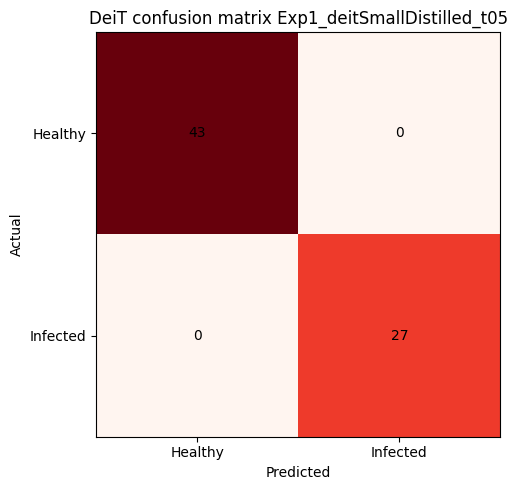

Accuracy: 100.0 Baseline: 91.78 Diff: 8.22


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Logged to /kaggle/working/results/results.csv
Saved /kaggle/working/results/deit_best_model


In [5]:
test_output = trainer.predict(test_hf)
logits = test_output.predictions
labels = test_output.label_ids
if labels is None:
    labels = labels_from_dataset(test_hf)
if isinstance(logits, tuple):
    logits = (logits[0] + logits[1]) / 2
preds = np.argmax(logits, axis=-1)

print(classification_report(labels, preds, target_names=["Healthy", "Infected"], digits=4))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Reds")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Healthy", "Infected"])
ax.set_yticklabels(["Healthy", "Infected"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("DeiT confusion matrix " + Experiment_Name)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "deit_cm_" + Experiment_Name + ".png"), dpi=150)
plt.show()

deit_acc = accuracy_score(labels, preds) * 100
deit_prec = precision_score(labels, preds, average="weighted", zero_division=0) * 100
deit_rec = recall_score(labels, preds, average="weighted", zero_division=0) * 100
deit_f1 = f1_score(labels, preds, average="weighted", zero_division=0) * 100

print("Accuracy:", round(deit_acc, 2), "Baseline:", BASELINE_ACC, "Diff:", round(deit_acc - BASELINE_ACC, 2))

DEIT_SAVE = os.path.join(save_dir, "deit_best_model")
trainer.save_model(DEIT_SAVE)
config["DEIT_SAVE"] = DEIT_SAVE
with open(WORKING_CONFIG, "w") as f:
    json.dump(config, f, indent=2)
log_result(Experiment_Name, "DeiT-Small-Distilled", deit_acc, deit_prec, deit_rec, deit_f1,
           Confidence_Threshold, deit_variant, dataset_version)
print("Saved", DEIT_SAVE)

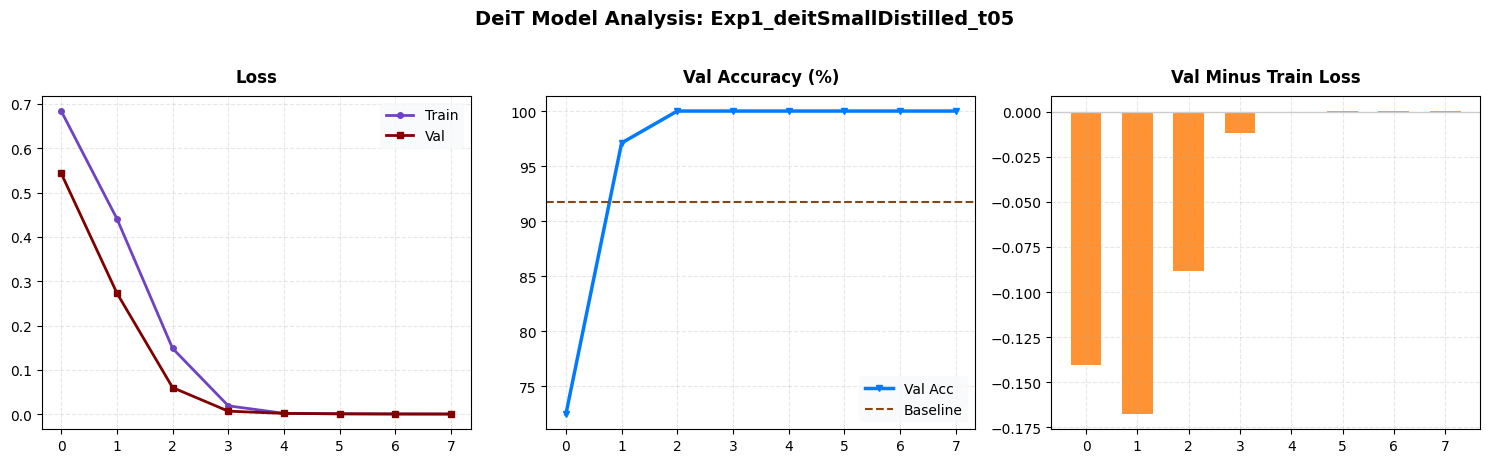

In [6]:
logs = trainer.state.log_history
tr_losses = [l["loss"] for l in logs if "loss" in l and "eval_loss" not in l]
val_losses = [l["eval_loss"] for l in logs if "eval_loss" in l]
val_accs = [l["eval_accuracy"] * 100 for l in logs if "eval_accuracy" in l]

C_VIOLET = "#6F42C1"   
C_MAROON = "#800000"     
C_BLUE = "#007BFF"       
C_BROWN = "#8B4513"     
C_ORANGE = "#FF7F0E"      

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(tr_losses, label="Train", color=C_VIOLET, linewidth=2, marker='o', markersize=4)
axes[0].plot(val_losses, label="Val", color=C_MAROON, linewidth=2, marker='s', markersize=4)
axes[0].set_title("Loss", fontsize=12, fontweight="bold", pad=10)
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].legend(frameon=True, facecolor="#F8F9FA", edgecolor="none")

axes[1].plot(val_accs, color=C_BLUE, linewidth=2.5, marker='v', markersize=5, label="Val Acc")
axes[1].axhline(BASELINE_ACC, linestyle="--", color=C_BROWN, linewidth=1.5, label="Baseline")
axes[1].set_title("Val Accuracy (%)", fontsize=12, fontweight="bold", pad=10)
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].legend(frameon=True, facecolor="#F8F9FA", edgecolor="none")

if len(tr_losses) == len(val_losses):
    gap = [v - t for v, t in zip(val_losses, tr_losses)]
    
    axes[2].bar(range(len(gap)), gap, color=C_ORANGE, edgecolor="none", alpha=0.85, width=0.6)
    axes[2].axhline(0, color="#CCCCCC", linewidth=1)
    axes[2].set_title("Val Minus Train Loss", fontsize=12, fontweight="bold", pad=10)
    axes[2].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("DeiT Model Analysis: " + Experiment_Name, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(save_dir, "deit_history_" + Experiment_Name + ".png"), dpi=200, bbox_inches="tight")
plt.show()

In [7]:
def cross_validate(n_splits=5):
    samples = load_samples(train_ann, train_img_dir)
    lbls = [s["label"] for s in samples]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_accs = []
    for fold, (tr_i, val_i) in enumerate(skf.split(samples, lbls)):
        tr_ds = HFDataset.from_list([samples[i] for i in tr_i])
        val_ds = HFDataset.from_list([samples[i] for i in val_i])
        tr_ds = tr_ds.map(preprocess_train, remove_columns=tr_ds.column_names)
        val_ds = val_ds.map(preprocess_eval, remove_columns=val_ds.column_names)
        for ds in [tr_ds, val_ds]:
            ds.set_format("torch", columns=["pixel_values", "labels"])
        m = DeiTForImageClassificationWithTeacher.from_pretrained(
            deit_variant, num_labels=2, ignore_mismatched_sizes=True)
        fa = TrainingArguments(
            output_dir="/tmp/fold_" + str(fold), num_train_epochs=10,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            learning_rate=lr_deit, weight_decay=weight_decay,
            eval_strategy="epoch", save_strategy="no", logging_strategy="no",
            report_to="none", fp16=torch.cuda.is_available(), seed=SEED,
            remove_unused_columns=False, dataloader_num_workers=0,
            label_names=["labels"],) 
        ft = DeiTDistilledTrainer(
            model=m, args=fa, train_dataset=tr_ds, eval_dataset=val_ds,
            data_collator=deit_collate_fn, compute_metrics=compute_metrics)
        ft.train()
        val_labels = labels_from_dataset(val_ds)
        res = ft.predict(val_ds)
        raw = res.predictions
        if isinstance(raw, tuple):
            raw = (raw[0] + raw[1]) / 2
        preds = np.argmax(raw, axis=-1)
        y_true = res.label_ids if res.label_ids is not None else val_labels
        acc = accuracy_score(y_true, preds) * 100
        fold_accs.append(acc)
        print("Fold", fold + 1, "accuracy", round(acc, 2))
        del m, ft
        torch.cuda.empty_cache()
    print("CV mean", round(np.mean(fold_accs), 2), "std", round(np.std(fold_accs), 2))
    return fold_accs

cv_accs = cross_validate(5)

Map:   0%|          | 0/259 [00:00<?, ? examples/s]

Map:   0%|          | 0/65 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

DeiTForImageClassificationWithTeacher LOAD REPORT from: facebook/deit-small-distilled-patch16-224
Key                            | Status   |                                                                                        
-------------------------------+----------+----------------------------------------------------------------------------------------
cls_classifier.weight          | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
cls_classifier.bias            | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.237427,0.953846,0.954581,0.953846,0.953982
2,No log,0.062364,1.000000,1.000000,1.000000,1.000000
3,No log,0.016649,1.000000,1.000000,1.000000,1.000000
4,No log,0.006203,1.000000,1.000000,1.000000,1.000000
5,No log,0.003837,1.000000,1.000000,1.000000,1.000000
6,No log,0.003079,1.000000,1.000000,1.000000,1.000000
7,No log,0.002666,1.000000,1.000000,1.000000,1.000000
8,No log,0.002429,1.000000,1.000000,1.000000,1.000000
9,No log,0.002309,1.000000,1.000000,1.000000,1.000000
10,No log,0.002269,1.000000,1.000000,1.000000,1.000000


...

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

DeiTForImageClassificationWithTeacher LOAD REPORT from: facebook/deit-small-distilled-patch16-224
Key                            | Status   |                                                                                        
-------------------------------+----------+----------------------------------------------------------------------------------------
cls_classifier.weight          | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
cls_classifier.bias            | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
distillation_classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.273331,0.953125,0.953916,0.953125,0.953280
2,No log,0.098132,1.000000,1.000000,1.000000,1.000000
3,No log,0.046855,1.000000,1.000000,1.000000,1.000000
4,No log,0.018120,1.000000,1.000000,1.000000,1.000000
5,No log,0.013919,1.000000,1.000000,1.000000,1.000000
6,No log,0.009503,1.000000,1.000000,1.000000,1.000000
7,No log,0.007842,1.000000,1.000000,1.000000,1.000000
8,No log,0.007150,1.000000,1.000000,1.000000,1.000000
9,No log,0.006886,1.000000,1.000000,1.000000,1.000000
10,No log,0.006812,1.000000,1.000000,1.000000,1.000000


Fold 5 accuracy 100.0
CV mean 100.0 std 0.0
